# Industrial Surface Defect Classification using Transfer Learning 

## Objective

The aim of this assignment is to automatically classify surface defects in steel materials using real-world industrial image data and a transfer learning approach.

Surface defects such as cracks, scratches, inclusions, and pits commonly occur during manufacturing processes and can significantly affect product quality. Manual inspection of these defects is time-consuming, inconsistent, and difficult to scale.

In this assignment, we use a dataset containing steel surface images belonging to six different defect categories:
- Crazing  
- Inclusion  
- Patches  
- Pitted Surface  
- Rolled-in Scale  
- Scratches  

All defect types originate from the same manufacturing domain, and learning from all categories together allows the model to capture shared texture and structural patterns present across industrial surfaces.

The problem statement for this assignment is:

> **Given a steel surface image, predict the type of surface defect present in the image using a pretrained convolutional neural network.**

To solve this problem efficiently, we apply **transfer learning** by reusing a pretrained `MobileNetV2` model as a feature extractor and training only a lightweight classification head. This demonstrates how deep learning models can be adapted to real industrial use cases using limited data and computational resources.

## Business Value

In manufacturing industries such as steel, automotive, and heavy engineering, surface defects can directly impact product quality, safety, customer satisfaction, production cost, and rework rates.

Traditional inspection methods rely heavily on human inspectors, which introduces inconsistency in defect detection. Manual inspection also comes with high operational costs and scalability limitations.

By applying transfer learning, organisations can:
- Reuse pretrained visual intelligence instead of training models from scratch  
- Reduce development and training time  
- Achieve reliable defect detection even with smaller datasets  
- Deploy lightweight models suitable for real-time or edge-based inspection systems

## Dataset Description

This assignment uses the **NEU Surface Defect Dataset**, a real-world industrial dataset commonly used in manufacturing research and automated inspection systems.

### Dataset Characteristics:
- Images represent steel surface textures captured under industrial conditions  
- Each image belongs to one of six defect categories:
  - Crazing  
  - Inclusion  
  - Patches  
  - Pitted Surface  
  - Rolled-in Scale  
  - Scratches  
- Images are originally grayscale
- The dataset is reasonably balanced across classes  


#### Why this dataset?

- It represents a real industrial computer vision problem
- Defect patterns are texture-based, making it ideal for demonstrating transfer learning  
- The dataset size is moderate, encouraging the use of **partial transfer learning** rather than full model retraining  

## Flow Diagram

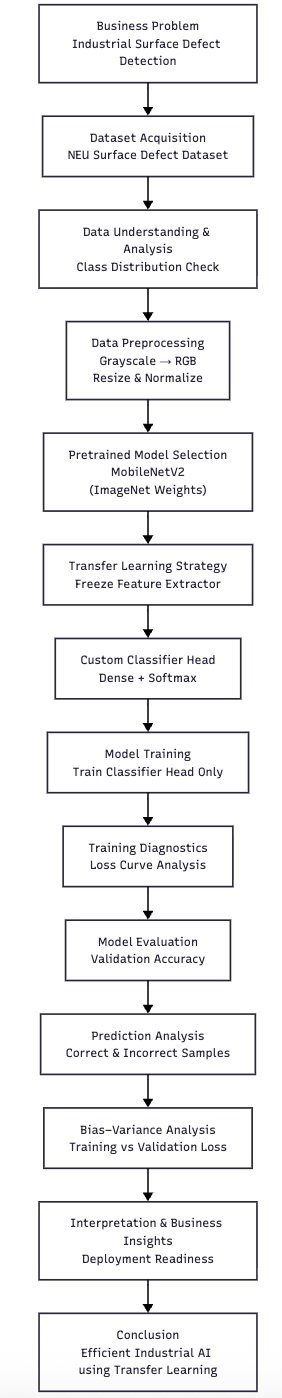

**Note:** You are free to choose any pre-trained model from the available ones. However, the architecture we suggest for this assignment is `MobileNetV2` with "ImageNet" weights.

The choice of libraries, frameworks, and backbones for this assignment are up to you. Before starting this assignment, please ensure that your environment meets the following requirements.


**Software Requirements**

- *Python version*: > Python3.11  
- *Execution environment*: Jupyter Notebook / JupyterLab / VS Code Notebook  
- *Operating system*: macOS, Linux, or Windows  


**Hardware Requirements**
- A GPU-powered training would be optimal, and would require installation of proper libraries and CUDA
- However, CPU-only execution might also be sufficient, and would work without CUDA

### Import Necessary libraries

In [2]:
!pip install --upgrade pip
!pip install tensorflow 

In [3]:
# Import Required Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report, recall_score


## 1. Data Loading and Preparation 

<font color=red>[10 marks]</font>

In any machine learning workflow, understanding and preparing the data correctly is a critical first step. Before building a deep learning model, it is important
to examine how the dataset is structured, how labels are assigned, and how images are preprocessed for training.

This section includes the following steps:
- Understanding the dataset organisation
- Verifying class labels and distributions
- Applying appropriate image transformations for transfer learning
- Development of train loader and validation loader

### 1.1 Dataset Understanding and Structure 

<font color=red>[4 marks]</font>

The NEU Surface Defect Dataset consists of real-world grayscale images collected from steel manufacturing processes. Each image belongs to one of six surface defect categories.

The dataset is already split into **training** and **validation** sets, and images are organised into class-specific folders. This structure allows us to use PyTorch’s `ImageFolder` utility, which automatically assigns labels based on directory names.

The same directory-based structure is also compatible with TensorFlow, allowing the dataset to be loaded directly using `tf.keras.utils.image_dataset_from_directory`, which infers class labels from folder names in a similar manner.



Before proceeding, we load the dataset and verify:
- Number of images in training and validation sets
- Mapping between class names and numeric labels

#### **1.1.1** Load Images and Labels  <font color=red>[3 marks]</font>

Load the training and validation datasets and check the number of images and the number of categories present

In [4]:
# Load training and validation images + labels

dataset_dir = r"C:\Users\sahai\Documents\NEU-DET"
train_dir = os.path.join(dataset_dir, "train", "images")
val_dir = os.path.join(dataset_dir, "validation", "images")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="int",
    shuffle=True,
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="int",
    shuffle=False
)
# Dataset statistics
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 1440 files belonging to 6 classes.
Found 360 files belonging to 6 classes.
Class names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of classes: 6


Assumptions:

Since the training images are stored class-wise in folders, the loader may otherwise see many images from the same class together. Shuffling mixes batches across classes, which helps training because each batch gives the model a more representative learning signal.

For validation, I am keeping, shuffle=False, because validation is not used to update weights. Keeping it ordered makes evaluation, confusion matrix generation, and sample prediction visualization easier to trace back.

Here, the image loader automatically assigns numeric labels based on folder names. For example, all images inside the "crazing" folder receive the same label.

This approach reduces manual labeling effort and ensures consistency between directory structure and class definitions.

#### **1.1.2** Check and Visualise Class Distribution <font color=red>[1 mark]</font>

In [5]:
# Dataset Class Distribution
def get_image_files(class_path):
    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]
    return image_files

train_class_counts = {}
val_class_counts = {}

for class_name in class_names:
    train_class_path = os.path.join(train_dir, class_name)
    val_class_path = os.path.join(val_dir, class_name)
    train_count = len(get_image_files(train_class_path))
    val_count = len(get_image_files(val_class_path))
    train_class_counts[class_name] = train_count
    val_class_counts[class_name] = val_count 

print("Training class distribution:", train_class_counts)
print("Validation class distribution:", val_class_counts)

Training class distribution: {'crazing': 240, 'inclusion': 240, 'patches': 240, 'pitted_surface': 240, 'rolled-in_scale': 240, 'scratches': 240}
Validation class distribution: {'crazing': 60, 'inclusion': 60, 'patches': 60, 'pitted_surface': 60, 'rolled-in_scale': 60, 'scratches': 60}


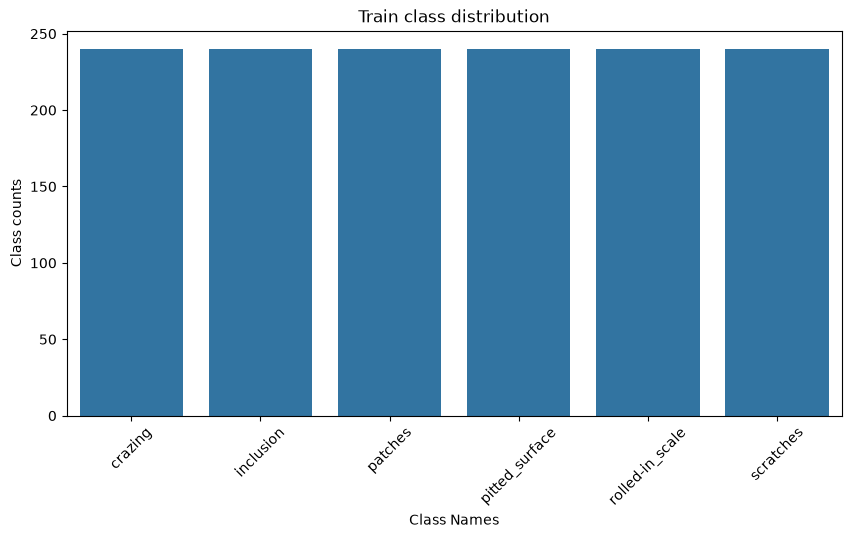

In [6]:
# Visualise class distribution
plt.figure(figsize=(10,5))
sns.barplot(
    x=list(train_class_counts.keys()),
    y=list(train_class_counts.values()))
plt.title("Train class distribution")
plt.xlabel("Class Names")
plt.ylabel("Class counts")
plt.xticks(rotation=45)
plt.show()

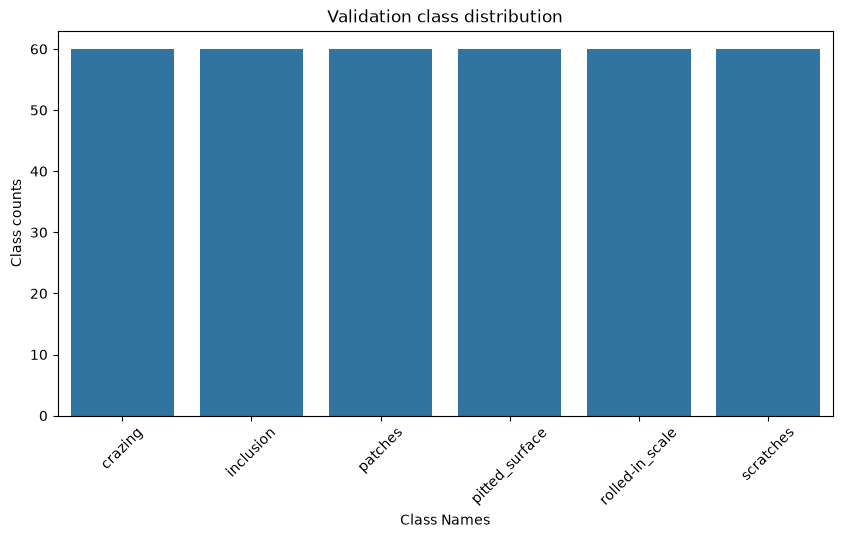

In [7]:
# Validation class distribution plot
plt.figure(figsize=(10,5))
sns.barplot(
    x=list(val_class_counts.keys()),
    y=list(val_class_counts.values()))
plt.title("Validation class distribution")
plt.xlabel("Class Names")
plt.ylabel("Class counts")
plt.xticks(rotation=45)
plt.show()

### 1.2 Data Preprocessing and Transformations 

<font color=red>[6 marks]</font>

Deep learning models pretrained on ImageNet expect images to be in a specific format. Although the NEU dataset images are grayscale, ImageNet-pretrained models require 3-channel RGB images with standardised dimensions and normalisation.

#### **1.2.1** Apply Image Transformations <font color=red>[4 marks]</font>

To ensure compatibility, we apply the following transformations:
- Convert grayscale images to RGB
- Resize images to a fixed resolution
- Normalize using ImageNet mean and standard deviation

These transformations are provided in [`transforms`](https://docs.pytorch.org/vision/0.24/transforms.html) from `torchvision`, while in TensorFlow the same preprocessing steps are applied using [`tf.image`](https://www.tensorflow.org/api_docs/python/tf/image) operations and `tf.keras.layers` within the input pipeline.

In PyTorch, normalization can be performed using `Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)`.

In TensorFlow, the same effect is achieved by explicitly standardising the images with the ImageNet statistics, i.e. subtracting `IMAGENET_MEAN` and dividing by `IMAGENET_STD` using `tf.image` operations or a custom `tf.keras.layers.Layer` within the preprocessing pipeline.

In [8]:
# Image Transformations
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_images(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess_images, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(preprocess_images, num_parallel_calls=AUTOTUNE)

Assumptions:

In this step, we apply MobileNetV2-specific preprocessing to the image batches. The dataset loader has already resized all images to 224 x 224 and loaded them in RGB format using color_mode="rgb". Therefore, we do not repeat resizing or grayscale-to-RGB conversion here.

Since MobileNetV2 was pretrained on ImageNet with a specific input scaling convention, we use the model-specific preprocess_input function from tensorflow.keras.applications.mobilenet_v2. This converts image pixel values into the range expected by the pretrained MobileNetV2 weights. The labels are returned unchanged because preprocessing affects only the input images, not their class labels.

At this stage, the dataset is fully prepared for training a transfer learning model. Images are correctly formatted, normalized, and labeled, ensuring a smooth transition into model design and training.

#### **1.2.2** Create DataLoaders for both the training and validation datasets <font color=red>[2 marks]</font>


Deep learning models are trained on data in **batches** rather than loading the entire dataset into memory at once.

PyTorch provides the [`DataLoader`](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) utility to batch the data, shuffle training samples and load data efficiently during training. For Tensorflow, you can use similar functionality provided by [`tf.data.Dataset` API](https://www.tensorflow.org/api_docs/python/tf/data/Dataset), which supports efficient batching, shuffling, prefetching, and parallel data loading within the input pipeline.

In [9]:
# DataLoader Creation

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Assumption: 
In TensorFlow, datasets created using image_dataset_from_directory already behave like data loaders because they load images, assign labels, resize them and create batches. In this step, cache and prefetch are applied to improve input pipeline efficiency. cache keeps the processed data available after the first pass, while prefetch prepares the next batch while the model is training on the current batch.

Also decide on where to use shuffling - training or validation

## 2. Transferring Knowledge and Model Training

<font color=red>[25 marks]</font>

Training deep learning models from scratch requires large amounts of labeled data and computational resources. In many real-world scenarios, this is not feasible. Transfer learning addresses this challenge by reusing knowledge learned from a large source dataset (such as ImageNet) and adapting it to a new, related task.

### 2.1 Pretrained Model Selection

<font color=red>[15 marks]</font>

For this assignment, we will prefer **MobileNetV2**, a lightweight convolutional neural network pretrained on the ImageNet dataset. Though any pre-trained network will suit the task.

MobileNetV2 is computationally efficient and lightweight. It performs well on texture-based image classification tasks.

In this section:
- Select a suitable pretrained convolutional neural network
- Apply a partial transfer learning strategy
- Design a task-specific classifier for surface defect detection

#### **2.1.1** Load the Pre-Trained Model <font color=red>[5 marks]</font>

Load the pre-trained model of your choice. If you wish to use a different architecture from MobileNet, also explain the reason for your choice.

In [10]:
# Load Pretrained Network
base_model = MobileNetV2(
    weights = "imagenet", # Using pretrained imagenet weights
    include_top = False, # Removign classifier from base pre-trained model
    input_shape =(224, 224, 3) # For RGB 3 channels
)
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

Assumption -1:

MobileNetV2 is loaded with ImageNet pretrained weights so that the model can reuse visual features learned from a large image dataset. The top classification layer is excluded because the original classifier predicts 1000 ImageNet classes, whereas this task requires classification into six surface defect categories. Therefore, only the convolutional feature extractor is retained.

Assumption -2:

MobileNetV2 was selected because it is a lightweight pretrained CNN trained on ImageNet. Since the NEU-DET dataset is moderate in size, using MobileNetV2 as a frozen feature extractor allows the model to reuse generic visual patterns such as edges, textures and shapes while training only a small task-specific classifier for six surface defect categories.
MobileNetV2 is suitable for this assignment because it is lightweight, computationally efficient and works well with limited data and compute resources. As a pretrained ImageNet model, it can reuse general visual features such as edges, textures and shapes, while only a small classifier head needs to be trained for the six surface defect categories.

The MobileNetV2 architecture consists of two main components:
- A **feature extractor** that learns visual representations
- A **classifier head** originally designed for ImageNet’s 1000 classes

#### **2.1.2** Freezing Strategy and Classifier Design <font color=red>[8 marks]</font>

Build the transfer learning model by loading and freezing the feature extractor layers. 


Instead of retraining the entire network, we apply partial transfer learning. In this approach the pretrained feature extractor is frozen and only the classifier head is retrained for the new task. This strategy reduces the risk of overfitting and speeds up training.

In [11]:
# Build Transfer Learning Model
base_model.trainable = False
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs=base_model.input, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Assumption:

The pretrained MobileNetV2 base model is frozen by setting trainable to False. This prevents the ImageNet-learned convolutional filters from being updated during training. A new classifier head is added on top of the frozen feature extractor. GlobalAveragePooling2D converts the extracted feature maps into a compact feature vector, followed by a Dense layer and Dropout for regularization. The final Dense layer uses softmax activation to predict one of the six surface defect classes.

Only the newly added classifier head learns during training. The Dense layers train their weights, while the pretrained MobileNetV2 feature extractor remains frozen.

#### **2.1.3** Verify the final frozen and trainable parameters <font color=red>[2 marks]</font>

In [12]:
# Verify Freezing Strategy

trainable_params = np.sum([
    tf.keras.backend.count_params(w)
    for w in model.trainable_variables
])
non_trainable_params = np.sum([
    tf.keras.backend.count_params(w)
    for w in model.non_trainable_variables
])
print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Trainable parameters: 164742
Non-trainable parameters: 2257986


Observations: 

The number of non-trainable parameters is much higher than the number of trainable parameters, confirming that the pretrained MobileNetV2 feature extractor has been frozen. Only the newly added classifier head remains trainable, which is appropriate for partial transfer learning on a moderate-sized dataset.

### 2.2 Model Training 

<font color=red>[10 marks]</font>

After designing the transfer learning model, the next step is to train it on the prepared dataset.

We only train the classifier head, while the pretrained feature extractor remains frozen. This allows the model to adapt quickly to the surface defect classification task.

In this section, we:
- Configure the training setup
- Train the model for a small number of epochs
- Track training loss to verify learning progress

#### **2.2.1** Training Configuration <font color=red>[3 marks]</font>

Before starting the training loop, we define:
- The computation device: CPU or GPU
- The loss function: Use a suitable loss function (one of the cross-entropy losses would work fine here)
- The optimizer: preferably [Adam](https://arxiv.org/abs/1412.6980) from [Tensorflow](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) or [Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)

These components control how the model learns from data and how its parameters are updated during training.

In [13]:
# Training Configuration
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### **2.2.2** Model Training Loop <font color=red>[5 marks]</font>

Perform the training and track the training loss across epochs to verify whether the model is learning effectively.

The training loop iterates over the dataset multiple times (epochs). For each batch of images, the model:
- Performs a forward pass
- Computes the loss
- Updates the trainable parameters using backpropagation

In [14]:
# Model Training
EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10


c:\tfenvs\neu-tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 392ms/step - accuracy: 0.9076 - loss: 0.3155 - val_accuracy: 0.9944 - val_loss: 0.0418
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 353ms/step - accuracy: 0.9937 - loss: 0.0295 - val_accuracy: 0.9861 - val_loss: 0.0474
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 350ms/step - accuracy: 0.9965 - loss: 0.0222 - val_accuracy: 0.9917 - val_loss: 0.0304
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 528ms/step - accuracy: 0.9979 - loss: 0.0127 - val_accuracy: 0.9972 - val_loss: 0.0201
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 819ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.9972 - val_loss: 0.0170
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 866ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 0.0119
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 366ms/step - accuracy: 0.9979 - loss: 0.0055 - val_accuracy: 0.9944 - val_loss: 0.0215
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 349ms/step - accuracy: 0.9986 - loss: 0.0067 - val_accuracy: 0.997

Observation: 

The model is trained using Keras model.fit. During each epoch, the model processes all training batches once and updates only the trainable classifier head. Validation data is passed to monitor performance on unseen data after every epoch. The returned history object stores loss and accuracy values for both training and validation, which are later used for visualizing learning progress.

Observation: 

The model learned very quickly.
Training accuracy reaches almost 1.0, meaning the classifier head is fitting the training set extremely well.
Validation accuracy is also very high, around 0.98 to 1.00, so the model is generalizing well on the validation set.
Validation loss generally decreases from 0.0631 to around 0.0116, which is a good sign.

Best val_accuracy: epoch 8 with 1.0000

Best val_loss: epoch 9 with 0.0116

#### **2.2.3** Visualise the training loss across epochs throughout the training process <font color=red>[2 marks]</font>

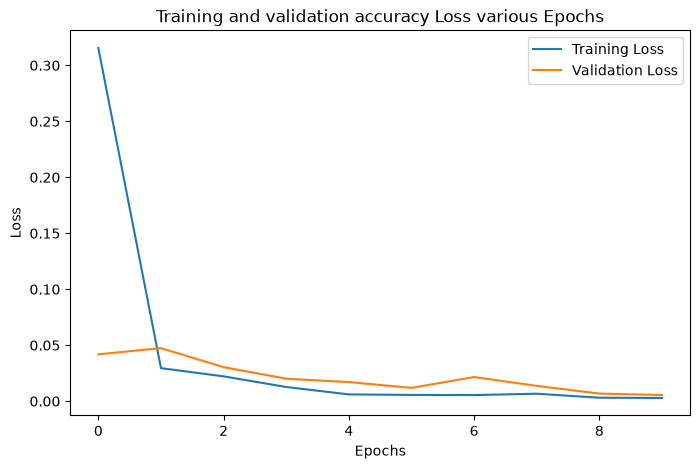

In [15]:
# Training Loss Visualisation
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Training and validation accuracy Loss various Epochs")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


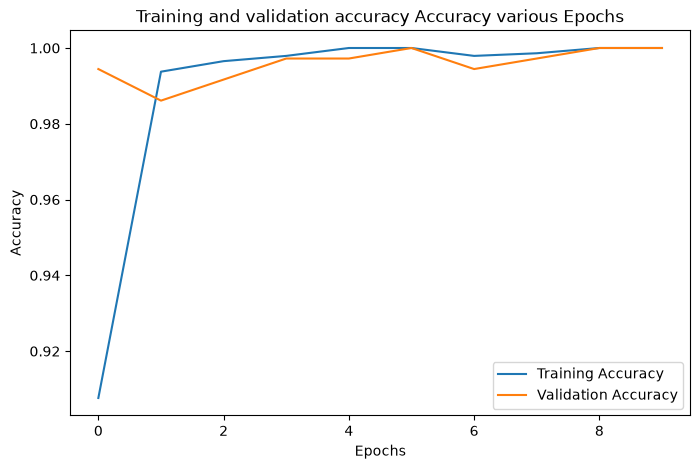

In [16]:
# Training Accuracy Visualisation
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Training and validation accuracy Accuracy various Epochs")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## 3. Evaluation and Final Predictions

<font color=red>[10 marks]</font>

After training the model, it is essential to evaluate how well it performs on unseen data. Evaluation helps us understand whether the model has learned generalisable patterns or has simply memorised the training data.

In this section, we:
- Measure model performance using validation accuracy
- Analyse predictions at the individual data-point level
- Examine model behavior using diagnostic plots

### 3.1 Evaluation Metrics and Bias-Variance Tradeoff

<font color=red>[6 marks]</font>

#### **3.1.1** Calculate Appropriate Evaluation Metrics to Assess Model Performance <font color=red>[3 marks]</font>

For this multi-class classification problem, we use **accuracy** as the primary evaluation metric.

Accuracy measures the proportion of validation samples that are correctly classified by the model. Since the dataset is reasonably balanced across classes, accuracy provides a reliable indication of overall performance.

In [17]:
# Model Evaluation

val_loss, val_accuracy = model.evaluate(val_ds)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)
y_true = []
y_pred = []
for images, labels in val_ds:
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)
print(classification_report(y_true, y_pred, target_names=class_names))


12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 1.0000 - loss: 0.0055
Validation Loss: 0.005509922746568918
Validation Accuracy: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      1.00      1.00        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      1.00      1.00        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       1.00      1.00      1.00        60

       accuracy       

Observation: 

The model achieved 100% accuracy on the available validation set. This indicates excellent performance on this split, but the result should still be interpreted cautiously because validation performance may not fully represent performance on completely new real-world images.

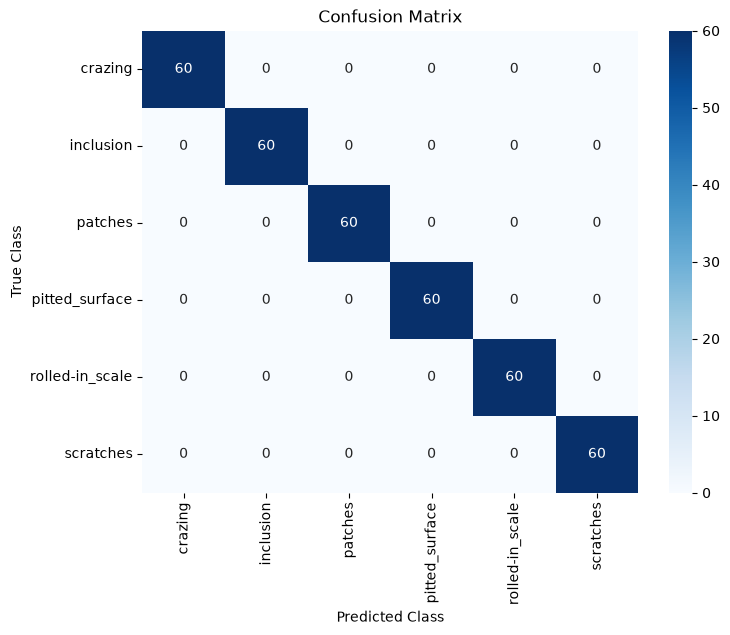

In [20]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

Observation:

- Training accuracy: near 1.0
- Validation accuracy: 1.0
- Validation loss: very low, around 0.0055
- Classification report: all classes precision/recall/F1 = 1.00
- Class distribution: balanced, 60 validation images per class



#### **3.1.2** Dataset Diagnostics <font color=red>[3 marks]</font>

Beyond accuracy, diagnostic analysis helps assess whether the model is underfitting, overfitting, or generalising well

Analyse this using training and validation loss trends, along with dataset class distribution.

In [21]:
# Training and Validation Loss Analysis
print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])


Final Training Loss: 0.0028398423455655575
Final Validation Loss: 0.005509922746568918
Final Training Accuracy: 1.0
Final Validation Accuracy: 1.0


Observation: 

The model does not show strong signs of underfitting or overfitting. Underfitting is unlikely because both training and validation losses are low and accuracies are high. Severe overfitting is also not evident because validation accuracy remains high and validation loss does not increase substantially while training loss decreases. The model appears to generalize well on the validation set.

### 3.2 Prediction Analysis

<font color=red>[4 marks]</font>

Overall accuracy provides a summary metric, but it does not reveal how individual predictions contribute to that score.

To better understand model behavior, we examine predictions at the individual image level, highlighting both correct and incorrect classifications.

#### **3.2.1** Visualise the prediction on a few sample images from validation set <font color=red>[4 marks]</font>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step


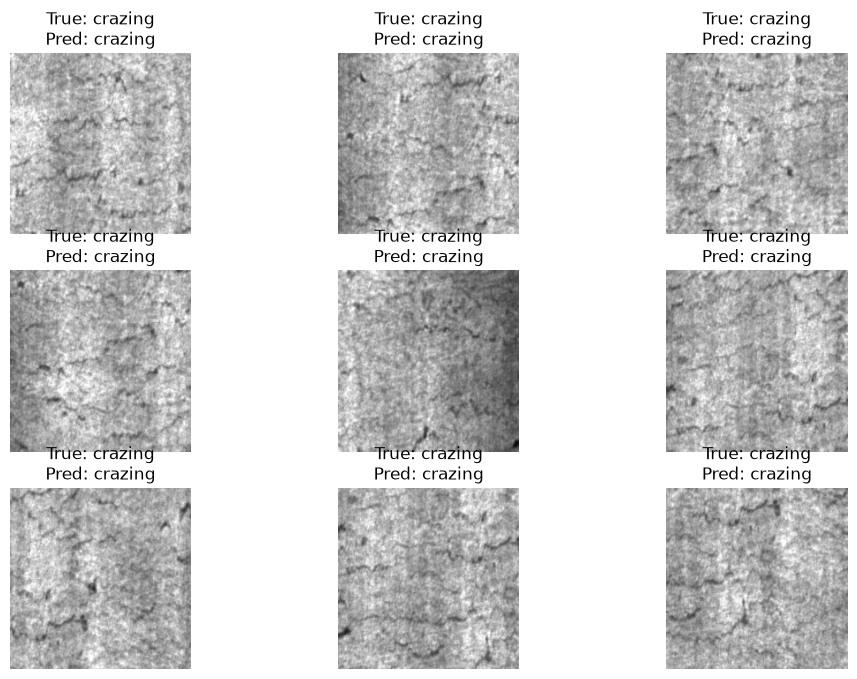

In [23]:
# Visualisation of Validation Predictions

for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    plt.figure(figsize=(12, 8))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        display_image = (images[i].numpy() + 1) / 2
        display_image = np.clip(display_image, 0, 1)
        plt.imshow(display_image)
        true_label = class_names[labels[i].numpy()]
        predicted_label = class_names[predicted_labels[i]]
        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis("off")
    plt.show()

Observation: 

A single validation batch is used to visualize sample predictions. The model produces class probabilities for each image, and argmax is used to select the class with the highest probability. Since the validation images were preprocessed for MobileNetV2, the image values are converted back to a display-friendly range before plotting. Each image is shown with its true label and predicted label to visually inspect model behavior.

## 4 Conclusion 

<font color =red> [5 marks] </font>

### 4.1 Conclusion and insights

<font color =red> [5 marks] </font>

#### **4.1.1** Conclude with the insights drawn and final outcomes and results. Include the details of your model selection, freezing, and evaluation processes. <font color =red> [5 marks] </font>


*Answer below:*

- Model selection: MobileNetV2 was selected as the pretrained model because it is lightweight, computationally efficient and suitable for transfer learning with a moderate-sized image dataset. Its ImageNet pretrained weights allow the model to reuse general visual features such as edges, textures and shapes.

- Freezing and classifier design: The MobileNetV2 base was loaded with include_top=False to remove the original ImageNet classifier. The base layers were frozen so that only the newly added classifier head was trained. The classifier head used GlobalAveragePooling2D, a Dense layer with ReLU activation, Dropout for regularization and a final Dense layer with softmax activation for the six defect classes.

- Evaluation results: The model achieved 100% validation accuracy on the available validation set with very low validation loss. The classification report showed precision, recall and F1-score of 1.00 for all six classes, and the confusion matrix showed correct classification across the validation samples.

- Final insight: The training and validation trends suggest good generalization on the validation data, with no strong evidence of underfitting or severe overfitting. However, the perfect validation result should be interpreted cautiously and ideally confirmed on a separate unseen test set or real-world industrial images.